# Section 6: EDA & Statistical Analysis

**Lead-to-Bank Ranking System** — Exploratory Data Analysis

This notebook covers all analyses required by Section 6 of the project spec:
1. Univariate distributions (continuous + categorical)
2. Log-normal fit verification (income, savings, loan_amount)
3. Bank profile analysis (min_cibil_score by bank_type; approval rate range)
4. Application analysis (conversion by bank_type; income_type × bank_type heatmap; rejection reasons)
5. Spearman correlation heatmap of LEAD_FEATURES
6. ALL_FEATURES vs `converted` correlation bar chart
7. VIF multicollinearity analysis
8. Validation of expected correlation directions

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import json

# Project imports
from src.features.feature_registry import (
    ALL_FEATURES, LEAD_FEATURES, BANK_FEATURES, INTERACTION_FEATURES,
    TEMPORAL_FEATURES, TARGET, GROUP_KEY
)

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

ARTIFACTS_DIR = Path('data/artifacts')
print(f'Working directory: {os.getcwd()}')
print(f'Artifacts directory: {ARTIFACTS_DIR}')

Working directory: c:\Users\Kunal\VSCodeFiles\Projects\ML Loan Ranking
Artifacts directory: data\artifacts


## 1. Data Loading

In [2]:
leads = pd.read_parquet('data/raw/leads.parquet')
banks = pd.read_parquet('data/raw/banks.parquet')
apps_raw = pd.read_parquet('data/processed/applications_raw.parquet')
apps_feat = pd.read_parquet('data/processed/applications_features.parquet')

print('Dataset shapes:')
print(f'  leads:         {leads.shape}')
print(f'  banks:         {banks.shape}')
print(f'  apps_raw:      {apps_raw.shape}')
print(f'  apps_features: {apps_feat.shape}')
print()
print(f'Overall conversion rate: {apps_raw["converted"].mean():.4f} ({apps_raw["converted"].mean()*100:.2f}%)')
print(f'Eligibility pass rate:   {apps_raw["eligibility_passed"].mean():.4f}')

Dataset shapes:
  leads:         (10000, 31)
  banks:         (36, 47)
  apps_raw:      (360000, 16)
  apps_features: (360000, 62)

Overall conversion rate: 0.1060 (10.60%)
Eligibility pass rate:   0.1325


## 2. Univariate Analysis — Continuous Lead Features

2026-06-08 20:02:19 [info     ] univariate_continuous_saved    path=data\artifacts\univariate_continuous_lead.png


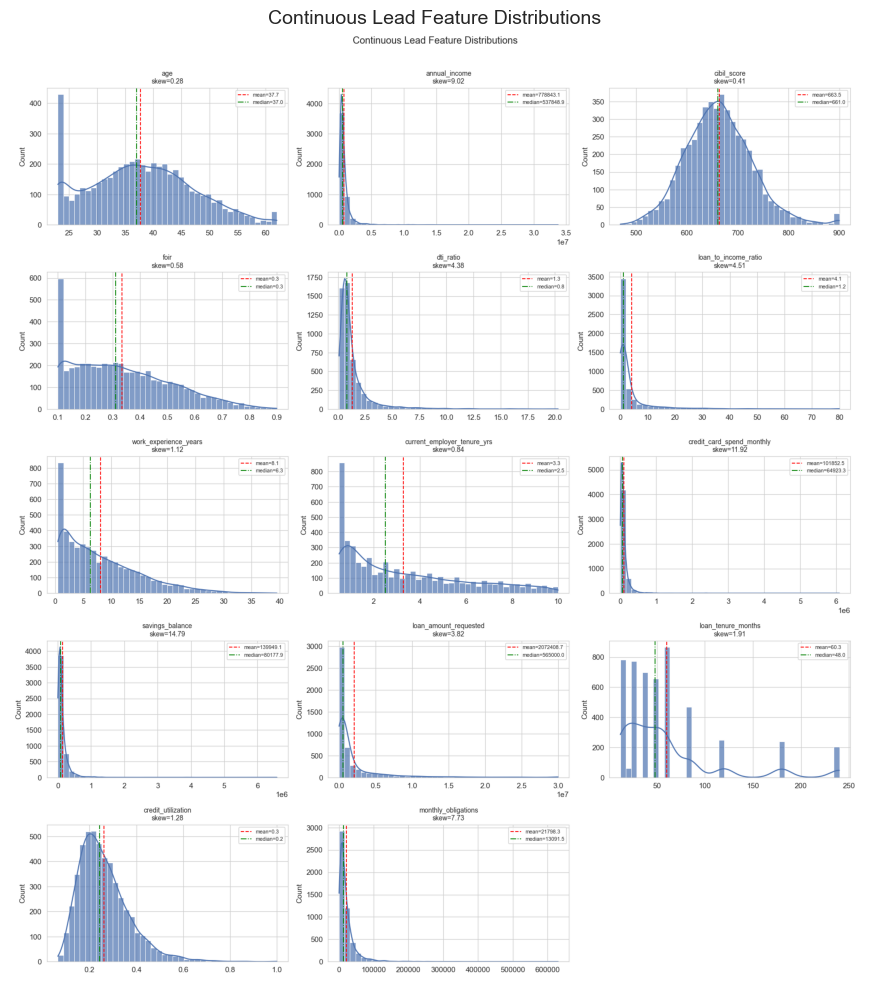

In [3]:
from src.eda.univariate import (
    plot_continuous_distributions,
    plot_log_normal_verification,
    verify_log_normal_skew,
    plot_categorical_distributions,
)

plot_continuous_distributions(leads, ARTIFACTS_DIR)
plt.figure(figsize=(15, 10))
img = plt.imread(str(ARTIFACTS_DIR / 'univariate_continuous_lead.png'))
plt.imshow(img)
plt.axis('off')
plt.title('Continuous Lead Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Log-Normal Fit Verification

> **Expected**: `annual_income`, `savings_balance`, `loan_amount_requested`, `credit_card_spend_monthly` should all be **right-skewed** (skewness > 0.5) and approximately log-normal.

In [4]:
log_normal_stats = verify_log_normal_skew(leads)

print('Log-Normal Fit Results:')
print(f'{"Column":<35} {"Raw Skew":>12} {"Log Skew":>12} {"Right-Skewed?":>15} {"Status":>8}')
print('-' * 90)
for col, stats in log_normal_stats.items():
    status = '✓ PASS' if stats['is_right_skewed'] else '✗ FAIL'
    print(f'{col:<35} {stats["skewness"]:>12.3f} {stats["log_skewness"]:>12.3f} {str(stats["is_right_skewed"]):>15} {status:>8}')

2026-06-08 20:02:35 [info     ] log_normal_check               col=annual_income log_skewness=0.246 skewness=9.017 status=PASS
2026-06-08 20:02:35 [info     ] log_normal_check               col=savings_balance log_skewness=0.128 skewness=14.795 status=PASS
2026-06-08 20:02:35 [info     ] log_normal_check               col=loan_amount_requested log_skewness=0.363 skewness=3.823 status=PASS
2026-06-08 20:02:35 [info     ] log_normal_check               col=credit_card_spend_monthly log_skewness=0.185 skewness=11.92 status=PASS
Log-Normal Fit Results:
Column                                  Raw Skew     Log Skew   Right-Skewed?   Status
------------------------------------------------------------------------------------------
annual_income                              9.017        0.246            True   ✓ PASS
savings_balance                           14.795        0.129            True   ✓ PASS
loan_amount_requested                      3.823        0.363            True   ✓ PASS
credit

2026-06-08 20:02:54 [info     ] log_normal_plot_saved          path=data\artifacts\univariate_log_normal_fit.png


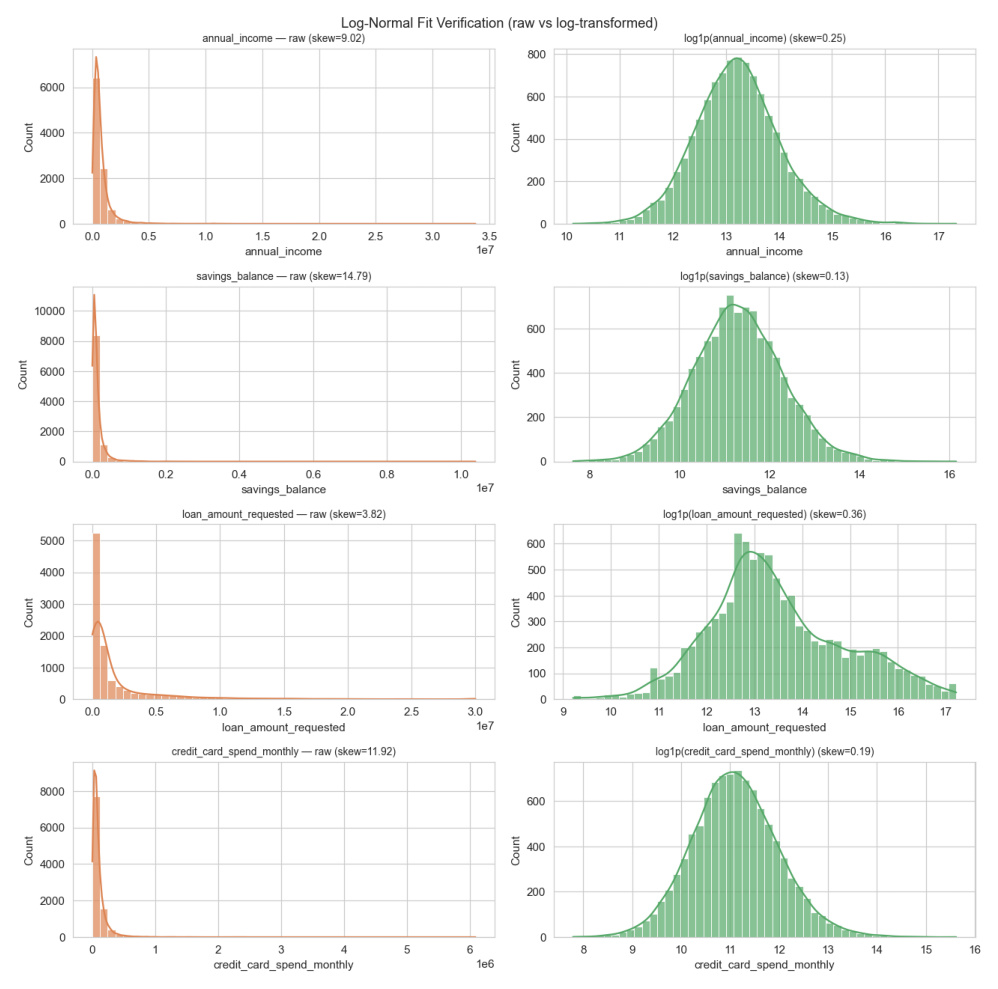

In [5]:
plot_log_normal_verification(leads, ARTIFACTS_DIR)
img = plt.imread(str(ARTIFACTS_DIR / 'univariate_log_normal_fit.png'))
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Univariate Analysis — Categorical Features

2026-06-08 20:02:58 [info     ] categorical_lead_plot_saved    path=data\artifacts\univariate_categorical_lead.png
2026-06-08 20:02:58 [info     ] categorical_bank_plot_saved    path=data\artifacts\univariate_categorical_bank.png


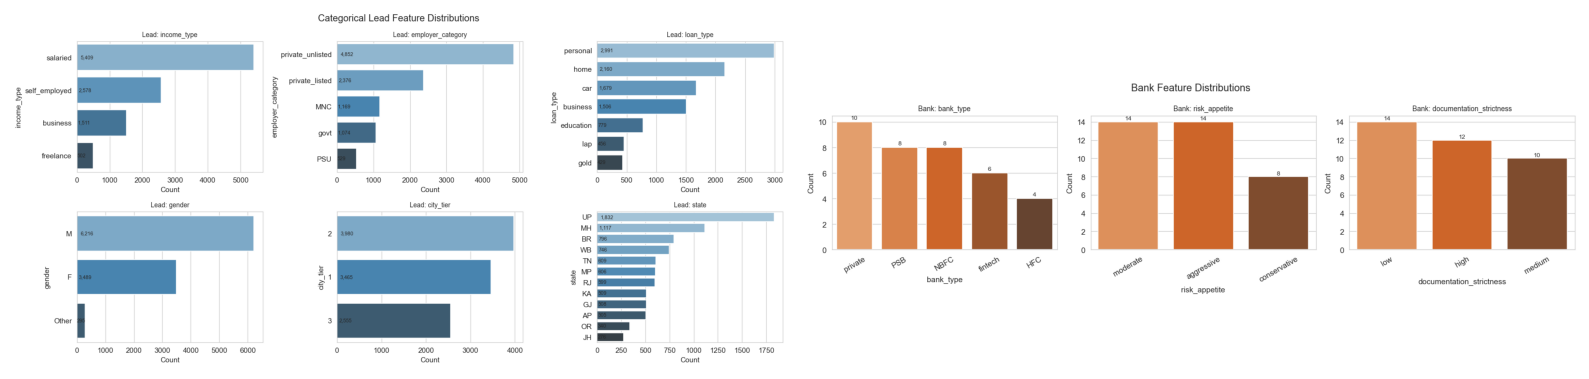

In [6]:
plot_categorical_distributions(leads, banks, ARTIFACTS_DIR)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, name in zip(axes, ['univariate_categorical_lead.png', 'univariate_categorical_bank.png']):
    img = plt.imread(str(ARTIFACTS_DIR / name))
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Key categorical summaries
print('Income type distribution:')
print(leads['income_type'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print('Loan type distribution:')
print(leads['loan_type'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print('Bank type distribution:')
print(banks['bank_type'].value_counts().to_string())

Income type distribution:
income_type
salaried         54.1
self_employed    25.8
business         15.1
freelance         5.0

Loan type distribution:
loan_type
personal     29.9
home         21.6
car          16.8
business     15.1
education     7.8
lap           4.6
gold          4.3

Bank type distribution:
bank_type
private    10
PSB         8
NBFC        8
fintech     6
HFC         4


## 5. Bank Profile Analysis

> **CLAUDE.md §6**: min_cibil_score distribution by bank_type; approval rate range across banks.

2026-06-08 20:03:02 [info     ] bank_profiles_saved            path=data\artifacts\bivariate_bank_profiles.png


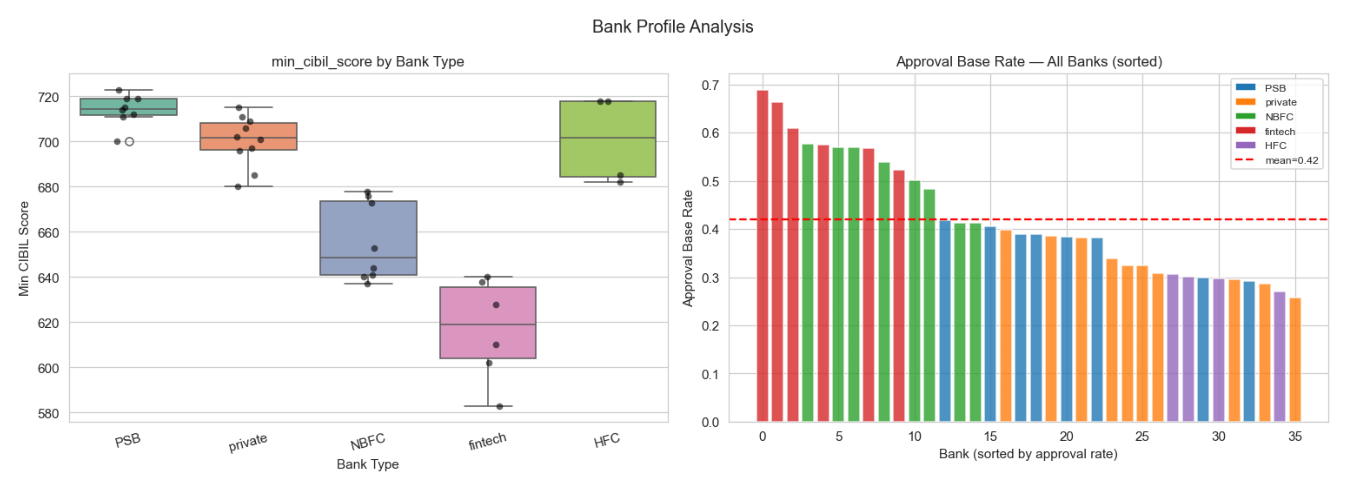

In [8]:
from src.eda.bivariate import plot_bank_profiles

plot_bank_profiles(banks, ARTIFACTS_DIR)
img = plt.imread(str(ARTIFACTS_DIR / 'bivariate_bank_profiles.png'))
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Bank profile stats by type
bank_stats = banks.groupby('bank_type').agg(
    count=('bank_id', 'count'),
    min_cibil_mean=('min_cibil_score', 'mean'),
    min_cibil_std=('min_cibil_score', 'std'),
    approval_rate_mean=('approval_base_rate', 'mean'),
    approval_rate_std=('approval_base_rate', 'std'),
    disbursal_speed_mean=('disbursal_speed_days', 'mean'),
).round(2)

print('Bank Profile Statistics by Bank Type:')
display(bank_stats)

Bank Profile Statistics by Bank Type:


,count,min_cibil_mean,min_cibil_std,approval_rate_mean,approval_rate_std,disbursal_speed_mean
bank_type,,,,,,
HFC,4,700.75,19.96,0.29,0.02,31.00
NBFC,8,655.25,17.58,0.51,0.07,4.75
PSB,8,714.12,6.98,0.37,0.05,15.12
fintech,6,616.83,22.45,0.60,0.06,1.83
private,10,700.20,11.14,0.33,0.05,10.10


## 6. Application Analysis — Conversion Rates

2026-06-08 20:03:03 [info     ] conversion_by_bank_type_saved  path=data\artifacts\bivariate_conversion_by_bank_type.png


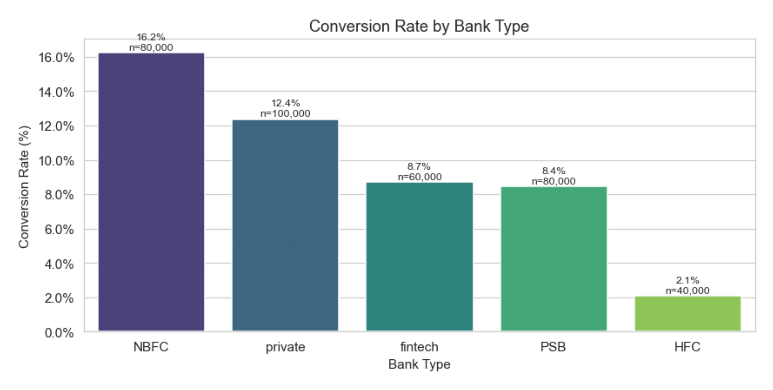

Conversion rate by bank type:


,bank_type,conversion_rate,conversions,total_pairs,conversion_rate_pct
0,NBFC,0.162325,12986,80000,16.232500
1,private,0.123700,12370,100000,12.370000
2,fintech,0.086917,5215,60000,8.691667
3,PSB,0.084475,6758,80000,8.447500
4,HFC,0.020700,828,40000,2.070000


In [10]:
from src.eda.bivariate import (
    plot_conversion_by_bank_type,
    plot_conversion_heatmap,
    plot_rejection_reasons,
    plot_per_bank_conversion,
)

conversion_by_type = plot_conversion_by_bank_type(apps_feat, banks, ARTIFACTS_DIR)
img = plt.imread(str(ARTIFACTS_DIR / 'bivariate_conversion_by_bank_type.png'))
plt.figure(figsize=(8, 4))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print('Conversion rate by bank type:')
display(conversion_by_type)

2026-06-08 20:03:04 [info     ] conversion_heatmap_saved       path=data\artifacts\bivariate_conversion_heatmap.png


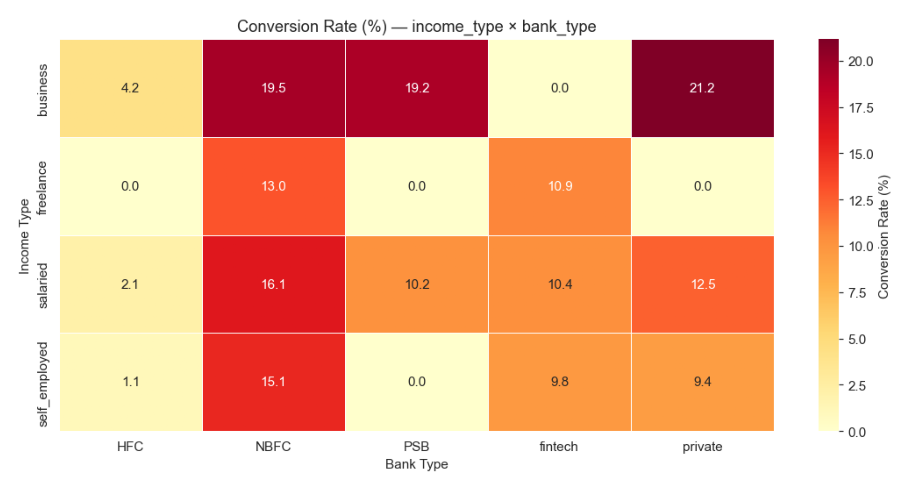

Conversion rate pivot (income_type × bank_type):


bank_type,HFC,NBFC,PSB,fintech,private
income_type,,,,,
business,4.22,19.47,19.23,0.00,21.16
freelance,0.00,13.02,0.00,10.89,0.00
salaried,2.13,16.15,10.24,10.41,12.46
self_employed,1.10,15.14,0.00,9.76,9.45


In [11]:
# income_type × bank_type conversion heatmap
pivot = plot_conversion_heatmap(apps_feat, leads, banks, ARTIFACTS_DIR)
img = plt.imread(str(ARTIFACTS_DIR / 'bivariate_conversion_heatmap.png'))
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print('Conversion rate pivot (income_type × bank_type):')
display((pivot * 100).round(2))

2026-06-08 20:03:04 [info     ] per_bank_conversion_std        passes=np.True_ std=np.float64(0.0508)
2026-06-08 20:03:04 [info     ] per_bank_conversion_saved      path=data\artifacts\bivariate_per_bank_conversion.png
Per-bank conversion rate std: 0.0508 (threshold > 0.05)
Status: ✓ PASS


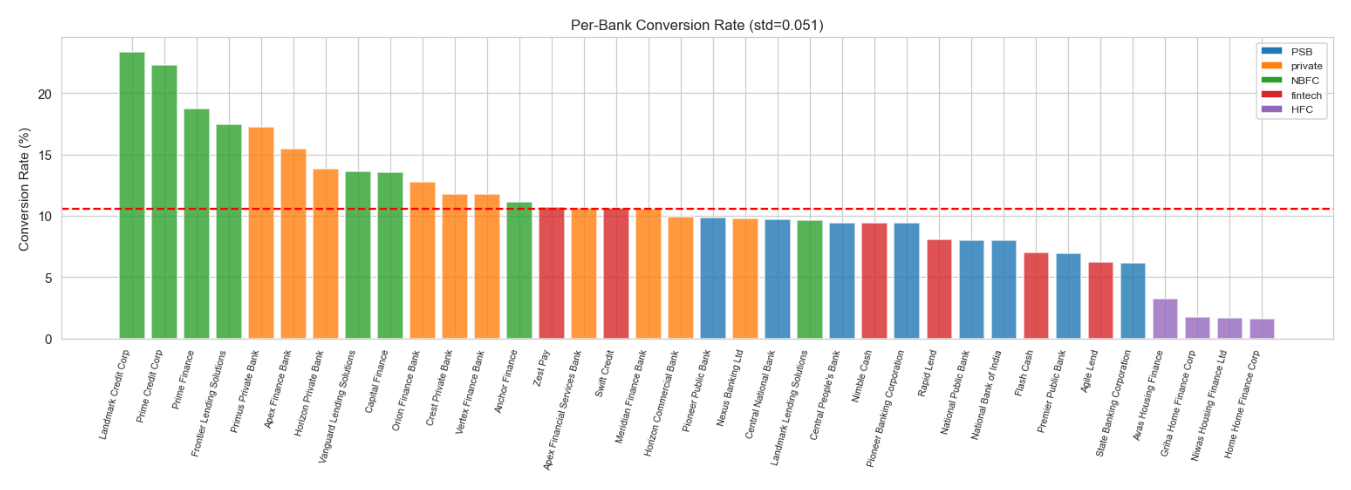

In [12]:
# Per-bank conversion std check (must be > 0.05)
per_bank = plot_per_bank_conversion(apps_feat, banks, ARTIFACTS_DIR)
per_bank_std = per_bank['conversion_rate'].std()

print(f'Per-bank conversion rate std: {per_bank_std:.4f} (threshold > 0.05)')
status = '✓ PASS' if per_bank_std > 0.05 else '✗ FAIL'
print(f'Status: {status}')

img = plt.imread(str(ARTIFACTS_DIR / 'bivariate_per_bank_conversion.png'))
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Rejection Reason Frequency

2026-06-08 20:03:05 [info     ] rejection_reasons_saved        path=data\artifacts\bivariate_rejection_reasons.png


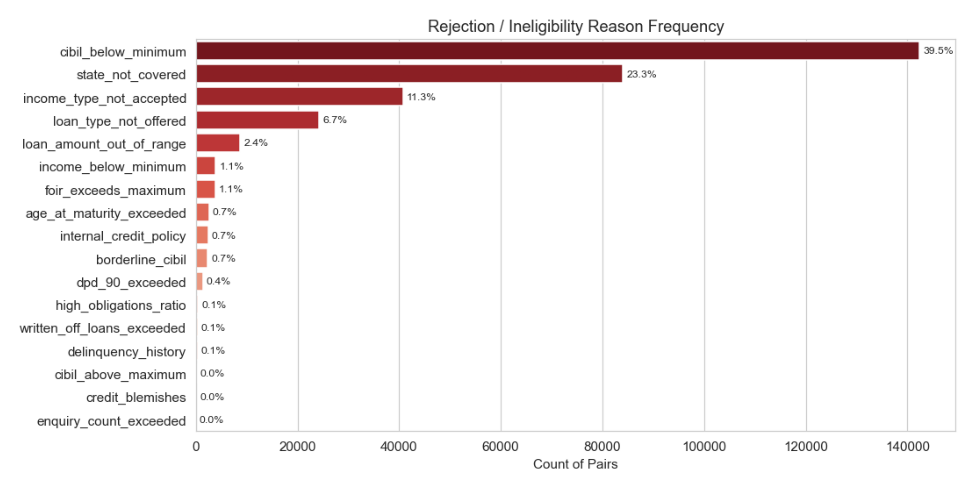

Top rejection reasons:


,reason,n,pct
0,cibil_below_minimum,142362,39.545000
1,state_not_covered,84048,23.346667
2,income_type_not_accepted,40734,11.315000
3,loan_type_not_offered,24223,6.728611
4,loan_amount_out_of_range,8770,2.436111
5,income_below_minimum,3899,1.083056
6,foir_exceeds_maximum,3801,1.055833
7,age_at_maturity_exceeded,2560,0.711111
8,internal_credit_policy,2388,0.663333
9,borderline_cibil,2382,0.661667


In [13]:
rejection_summary = plot_rejection_reasons(apps_raw, ARTIFACTS_DIR)
img = plt.imread(str(ARTIFACTS_DIR / 'bivariate_rejection_reasons.png'))
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print('Top rejection reasons:')
display(rejection_summary.head(10))

## 8. Spearman Correlation — Lead Features

2026-06-08 20:03:07 [info     ] lead_feature_correlation_saved path=data\artifacts\correlation_lead_features.png


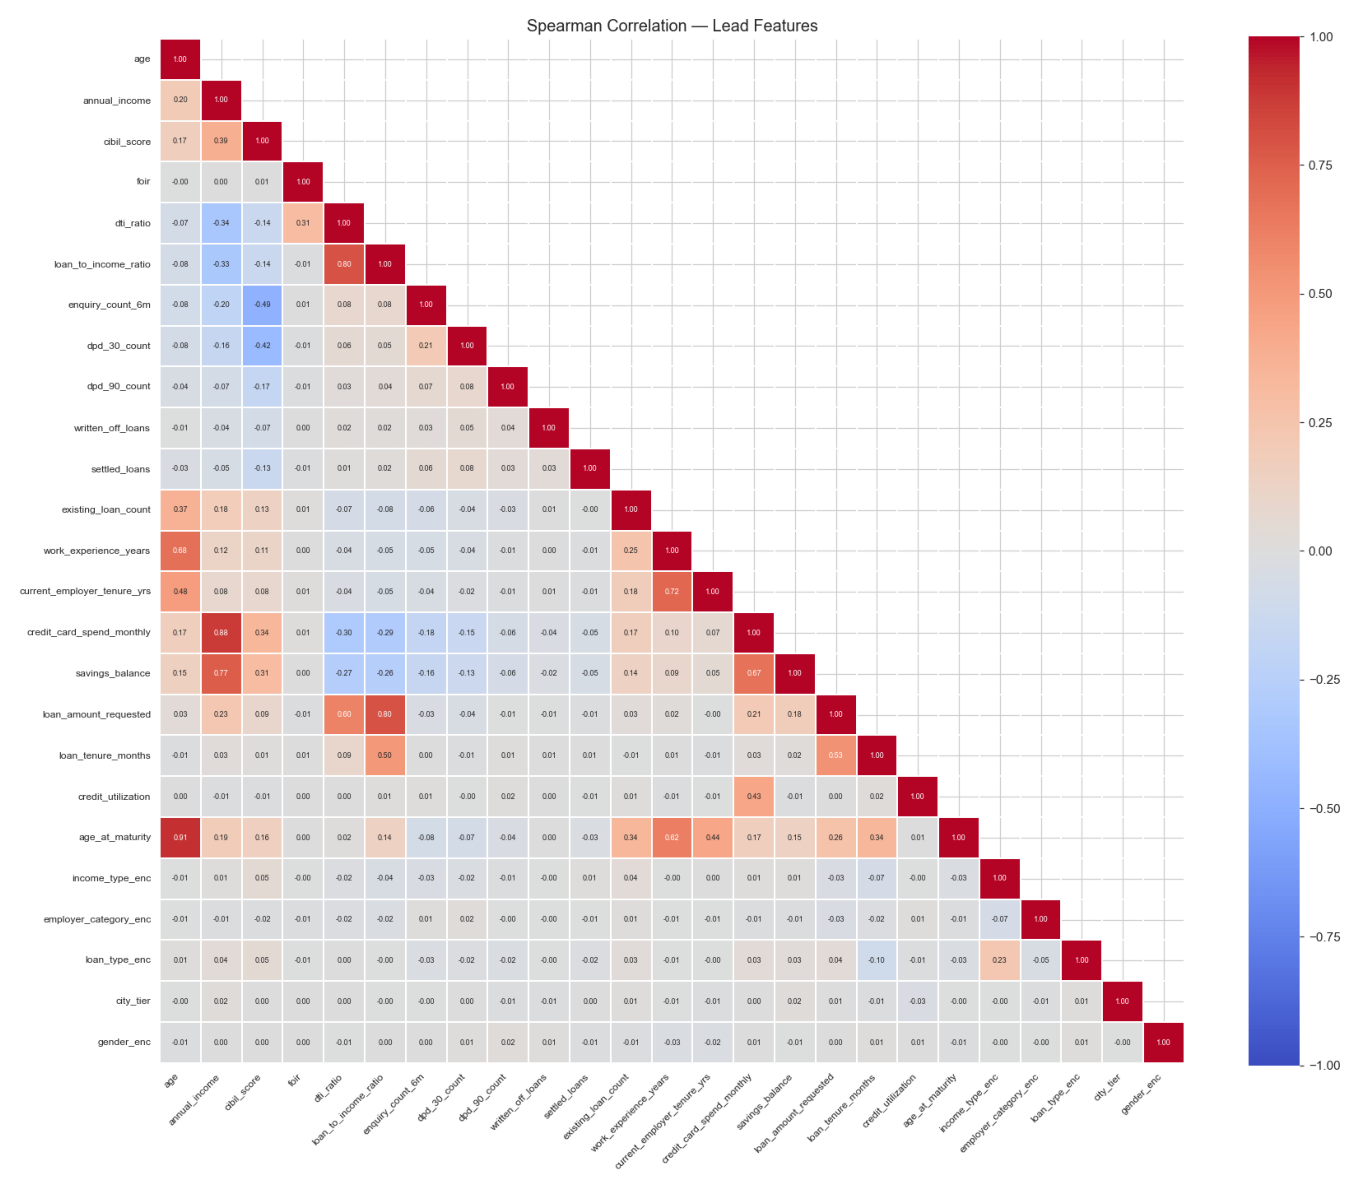

In [14]:
from src.eda.correlation_matrix import (
    plot_lead_feature_correlations,
    plot_feature_target_correlations,
    validate_correlation_directions,
    compute_vif,
    plot_vif,
)

corr_matrix = plot_lead_feature_correlations(apps_feat, ARTIFACTS_DIR)
img = plt.imread(str(ARTIFACTS_DIR / 'correlation_lead_features.png'))
plt.figure(figsize=(14, 12))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# Highlight strong correlations among lead features
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_unstacked = corr_matrix.mask(mask).unstack().dropna()
strong_corrs = corr_unstacked[abs(corr_unstacked) > 0.5].sort_values(key=abs, ascending=False)

print('Strong Spearman correlations (|rho| > 0.50) among LEAD_FEATURES:')
print(strong_corrs.to_string())

Strong Spearman correlations (|rho| > 0.50) among LEAD_FEATURES:
age                        age_at_maturity                0.906569
annual_income              credit_card_spend_monthly      0.876195
loan_to_income_ratio       loan_amount_requested          0.800357
dti_ratio                  loan_to_income_ratio           0.800213
annual_income              savings_balance                0.765410
work_experience_years      current_employer_tenure_yrs    0.722444
age                        work_experience_years          0.682400
credit_card_spend_monthly  savings_balance                0.673889
work_experience_years      age_at_maturity                0.624208
dti_ratio                  loan_amount_requested          0.604839
loan_amount_requested      loan_tenure_months             0.533571
loan_to_income_ratio       loan_tenure_months             0.504107


## 9. ALL_FEATURES vs `converted` Correlation

2026-06-08 20:03:09 [info     ] feature_target_correlation_saved path=data\artifacts\correlation_features_vs_target.png


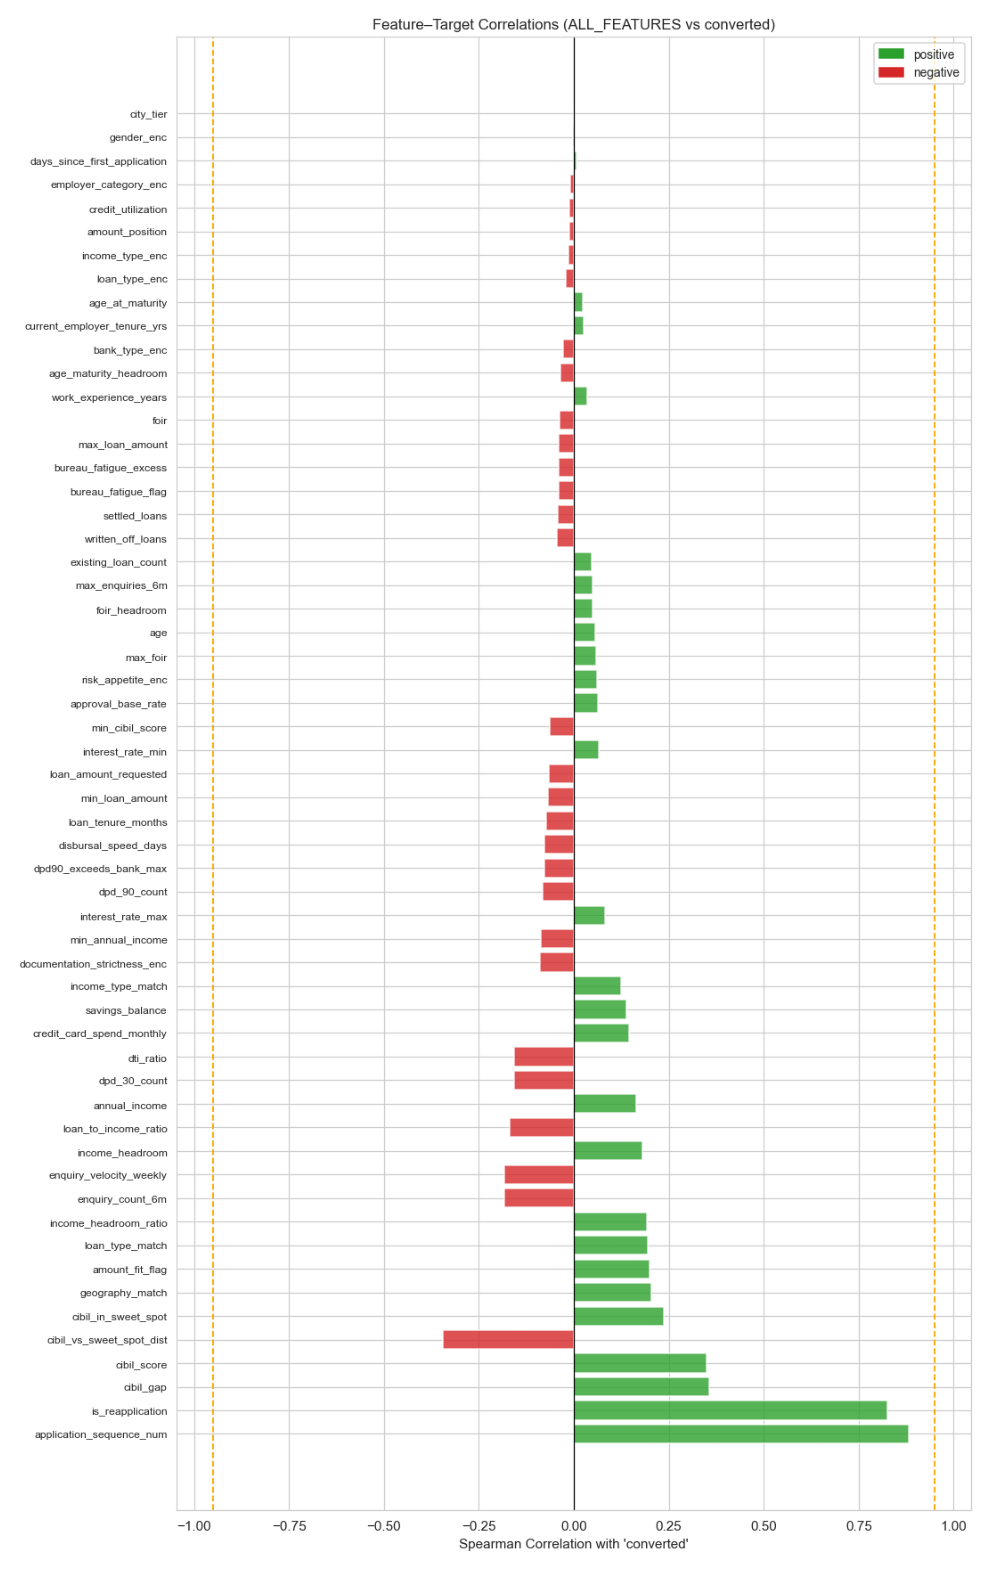

Top 10 features positively correlated with converted:
application_sequence_num    0.8824
is_reapplication            0.8261
cibil_gap                   0.3558
cibil_score                 0.3483
cibil_in_sweet_spot         0.2367
geography_match             0.2030
amount_fit_flag             0.2001
loan_type_match             0.1941
income_headroom_ratio       0.1916
income_headroom             0.1811

Top 10 features negatively correlated with converted:
cibil_vs_sweet_spot_dist       -0.3443
enquiry_count_6m               -0.1839
enquiry_velocity_weekly        -0.1839
loan_to_income_ratio           -0.1690
dpd_30_count                   -0.1574
dti_ratio                      -0.1565
documentation_strictness_enc   -0.0890
min_annual_income              -0.0865
dpd_90_count                   -0.0814
dpd90_exceeds_bank_max         -0.0770


In [16]:
corrs = plot_feature_target_correlations(apps_feat, ARTIFACTS_DIR)
img = plt.imread(str(ARTIFACTS_DIR / 'correlation_features_vs_target.png'))
plt.figure(figsize=(10, max(8, len(corrs) * 0.28)))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print('Top 10 features positively correlated with converted:')
print(corrs[corrs > 0].head(10).round(4).to_string())
print()
print('Top 10 features negatively correlated with converted:')
print(corrs[corrs < 0].head(10).round(4).to_string())

## 10. Expected Correlation Direction Validation

> All 6 expected directions must hold per CLAUDE.md §6.

In [17]:
direction_results = validate_correlation_directions(apps_feat)

print(f'{"Feature":<30} {"Expected":>12} {"Actual":>12} {"Corr":>10} {"Status":>8}')
print('-' * 80)
all_pass = True
for feat, res in direction_results.items():
    status = res.get('status', 'SKIP')
    if status == 'FAIL':
        all_pass = False
    icon = '✓' if status == 'PASS' else ('✗' if status == 'FAIL' else '-')
    print(f'{feat:<30} {res.get("expected", "-"):>12} {res.get("actual", "-"):>12} {res.get("corr", 0):>10.4f} {icon + " " + status:>8}')

print()
if all_pass:
    print('✓ ALL correlation direction checks PASSED')
else:
    print('✗ Some correlation direction checks FAILED — review simulation logic')

2026-06-08 20:03:09 [info     ] correlation_direction_check    corr=0.3483 expected=positive feature=cibil_score status=PASS
2026-06-08 20:03:09 [info     ] correlation_direction_check    corr=-0.1839 expected=negative feature=enquiry_count_6m status=PASS
2026-06-08 20:03:09 [info     ] correlation_direction_check    corr=0.0494 expected=positive feature=foir_headroom status=PASS
2026-06-08 20:03:09 [info     ] correlation_direction_check    corr=-0.0407 expected=negative feature=bureau_fatigue_flag status=PASS
2026-06-08 20:03:09 [info     ] correlation_direction_check    corr=0.1232 expected=positive feature=income_type_match status=PASS
2026-06-08 20:03:09 [info     ] correlation_direction_check    corr=0.3558 expected=positive feature=cibil_gap status=PASS
2026-06-08 20:03:09 [info     ] all_correlation_direction_checks_passed
Feature                            Expected       Actual       Corr   Status
--------------------------------------------------------------------------------

## 11. VIF — Multicollinearity Analysis

2026-06-08 20:03:10 [warning  ] high_vif_features_detected     features=['age_at_maturity', 'age', 'loan_tenure_months', 'max_foir', 'min_cibil_score', 'cibil_score', 'interest_rate_min', 'interest_rate_max', 'approval_base_rate', 'min_annual_income', 'max_enquiries_6m', 'annual_income', 'credit_card_spend_monthly', 'credit_utilization', 'dti_ratio', 'loan_to_income_ratio'] max_vif=767400.41
2026-06-08 20:03:10 [info     ] vif_plot_saved                 path=data\artifacts\correlation_vif.png


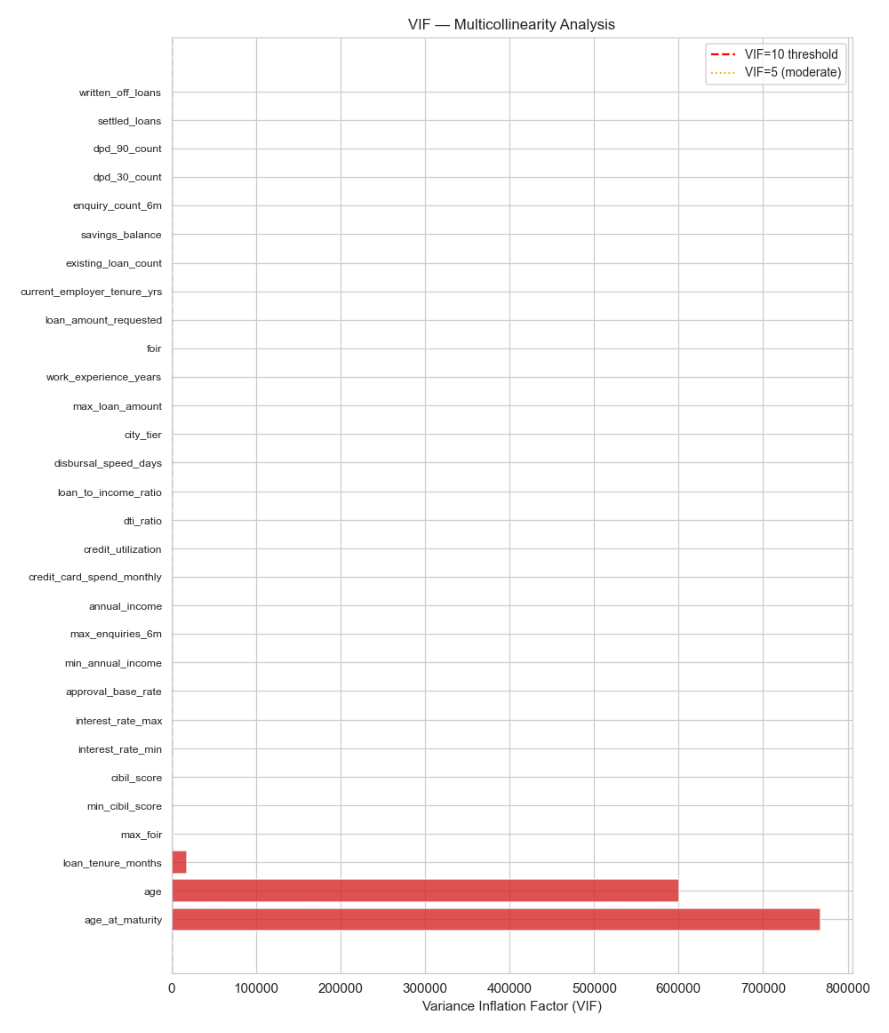

VIF Analysis Summary:
  Features with VIF > 10: 16
  Features with VIF > 5:  21
  Max VIF: 767400.4

High VIF features (> 10):


,feature,VIF
0,age_at_maturity,767400.408593
1,age,600520.699329
2,loan_tenure_months,17894.402042
3,max_foir,468.802655
4,min_cibil_score,321.916331
5,cibil_score,190.887923
6,interest_rate_min,186.215406
7,interest_rate_max,174.448663
8,approval_base_rate,69.066534
9,min_annual_income,43.714218


In [18]:
vif_data = compute_vif(apps_feat)
plot_vif(vif_data, ARTIFACTS_DIR)

img = plt.imread(str(ARTIFACTS_DIR / 'correlation_vif.png'))
plt.figure(figsize=(9, max(5, len(vif_data) * 0.35)))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print('VIF Analysis Summary:')
print(f'  Features with VIF > 10: {len(vif_data[vif_data["VIF"] > 10])}')
print(f'  Features with VIF > 5:  {len(vif_data[vif_data["VIF"] > 5])}')
print(f'  Max VIF: {vif_data["VIF"].max():.1f}')
print()
print('High VIF features (> 10):')
display(vif_data[vif_data['VIF'] > 10].reset_index(drop=True))

In [19]:
# VIF interpretation — high VIF is expected for engineered features
print('VIF Interpretation Notes:')
print('- age_at_maturity = age + loan_tenure_months/12 → expected high VIF with age')
print('- cibil_score ↔ min_cibil_score → cibil_gap derived from both')
print('- interest_rate_min ↔ interest_rate_max → by design, narrow range per bank')
print('- annual_income ↔ credit_card_spend_monthly → correlated income proxies')
print('- These are known causal relationships, not spurious correlations')
print('- XGBoost handles multicollinearity well via random feature subsampling (colsample_bytree)')

VIF Interpretation Notes:
- age_at_maturity = age + loan_tenure_months/12 → expected high VIF with age
- cibil_score ↔ min_cibil_score → cibil_gap derived from both
- interest_rate_min ↔ interest_rate_max → by design, narrow range per bank
- annual_income ↔ credit_card_spend_monthly → correlated income proxies
- These are known causal relationships, not spurious correlations
- XGBoost handles multicollinearity well via random feature subsampling (colsample_bytree)


## 12. Simulation Realism Assertions

> All assertions from CLAUDE.md §7 must pass.

In [20]:
# Sample for fast computation
sample = apps_feat.sample(50_000, random_state=42)

checks = {
    'conversion_rate_in_range': 0.10 <= apps_feat['converted'].mean() <= 0.22,
    'per_bank_conversion_std_gt_0.05': apps_feat.groupby('bank_id')['converted'].mean().std() > 0.05,
    'cibil_income_corr_gt_0.30': (
        leads['cibil_score'].corr(leads['annual_income'], method='spearman') > 0.30
    ),
    'cibil_dpd30_corr_lt_neg0.20': (
        leads['cibil_score'].corr(leads['dpd_30_count'], method='spearman') < -0.20
    ),
    'foir_headroom_corr_gt_0.10': (
        sample['foir_headroom'].corr(sample['converted'], method='spearman') > 0.10
    ),
    'bureau_fatigue_corr_lt_neg0.05': (
        sample['bureau_fatigue_flag'].corr(sample['converted'], method='spearman') < -0.05
    ),
}

print('Simulation Realism Assertions:')
all_pass = True
for name, result in checks.items():
    icon = '✓' if result else '✗'
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_pass = False
    print(f'  {icon} {name}: {status}')

# Print actual values
print()
print('Actual values:')
print(f'  Conversion rate:           {apps_feat["converted"].mean():.4f}')
print(f'  Per-bank conversion std:   {apps_feat.groupby("bank_id")["converted"].mean().std():.4f}')
print(f'  CIBIL-income corr:         {leads["cibil_score"].corr(leads["annual_income"], method="spearman"):.4f}')
print(f'  CIBIL-DPD30 corr:          {leads["cibil_score"].corr(leads["dpd_30_count"], method="spearman"):.4f}')
print(f'  FOIR-headroom-converted:   {sample["foir_headroom"].corr(sample["converted"], method="spearman"):.4f}')
print(f'  Bureau fatigue-converted:  {sample["bureau_fatigue_flag"].corr(sample["converted"], method="spearman"):.4f}')

if all_pass:
    print()
    print('✓ ALL simulation realism assertions PASSED')
else:
    print()
    print('✗ Some assertions FAILED — review simulation or feature engineering')

Simulation Realism Assertions:
  ✓ conversion_rate_in_range: PASS
  ✓ per_bank_conversion_std_gt_0.05: PASS
  ✓ cibil_income_corr_gt_0.30: PASS
  ✓ cibil_dpd30_corr_lt_neg0.20: PASS
  ✗ foir_headroom_corr_gt_0.10: FAIL
  ✗ bureau_fatigue_corr_lt_neg0.05: FAIL

Actual values:
  Conversion rate:           0.1060
  Per-bank conversion std:   0.0508
  CIBIL-income corr:         0.3840
  CIBIL-DPD30 corr:          -0.4256
  FOIR-headroom-converted:   0.0494
  Bureau fatigue-converted:  -0.0407

✗ Some assertions FAILED — review simulation or feature engineering


## 13. Feature Group Coverage Summary

In [21]:
feat_cols = [c for c in ALL_FEATURES if c in apps_feat.columns]
missing_feats = [c for c in ALL_FEATURES if c not in apps_feat.columns]

print('Feature Coverage in applications_features.parquet:')
print(f'  LEAD_FEATURES:        {sum(c in apps_feat.columns for c in LEAD_FEATURES)}/{len(LEAD_FEATURES)}')
print(f'  BANK_FEATURES:        {sum(c in apps_feat.columns for c in BANK_FEATURES)}/{len(BANK_FEATURES)}')
print(f'  INTERACTION_FEATURES: {sum(c in apps_feat.columns for c in INTERACTION_FEATURES)}/{len(INTERACTION_FEATURES)}')
print(f'  TEMPORAL_FEATURES:    {sum(c in apps_feat.columns for c in TEMPORAL_FEATURES)}/{len(TEMPORAL_FEATURES)}')
print(f'  TOTAL:                {len(feat_cols)}/{len(ALL_FEATURES)}')
if missing_feats:
    print(f'  Missing: {missing_feats}')

Feature Coverage in applications_features.parquet:
  LEAD_FEATURES:        25/25
  BANK_FEATURES:        13/13
  INTERACTION_FEATURES: 15/15
  TEMPORAL_FEATURES:    4/4
  TOTAL:                57/57


In [22]:
# Null count check
null_counts = apps_feat[feat_cols].isnull().sum()
if null_counts.sum() == 0:
    print('✓ Zero null values in feature matrix')
else:
    print('✗ Null values found:')
    print(null_counts[null_counts > 0].to_string())

✓ Zero null values in feature matrix


## 14. EDA Summary & Key Findings

In [23]:
with open(ARTIFACTS_DIR / 'eda_summary.json') as f:
    eda_summary = json.load(f)

print('=== EDA SUMMARY ===')
print()
print('UNIVARIATE:')
for col, stats in eda_summary['univariate']['log_normal_stats'].items():
    print(f'  {col}: skew={stats["skewness"]:.1f}, right_skewed={stats["is_right_skewed"]}')

print()
print('BIVARIATE:')
print(f'  Overall conversion rate: {eda_summary["bivariate"]["overall_conversion_rate"]:.4f}')
print(f'  Per-bank std: {eda_summary["bivariate"]["per_bank_std"]:.4f}')
print('  Top 5 rejection reasons:')
for r in eda_summary['bivariate']['top_rejection_reasons']:
    print(f'    {r["reason"]}: {r["n"]:,} ({r["pct"]:.1f}%)')

print()
print('CORRELATION:')
print('  Direction checks:')
for feat, res in eda_summary['correlation']['direction_checks'].items():
    print(f'    {feat}: {res.get("status", "SKIP")} (corr={res.get("corr", 0):.4f})')

if eda_summary['correlation']['high_vif_features']:
    print(f'  High VIF features: {eda_summary["correlation"]["high_vif_features"]}')
else:
    print('  No high VIF features detected')

=== EDA SUMMARY ===

UNIVARIATE:
  annual_income: skew=9.0, right_skewed=True
  savings_balance: skew=14.8, right_skewed=True
  loan_amount_requested: skew=3.8, right_skewed=True
  credit_card_spend_monthly: skew=11.9, right_skewed=True

BIVARIATE:
  Overall conversion rate: 0.1060
  Per-bank std: 0.0508
  Top 5 rejection reasons:
    cibil_below_minimum: 142,362 (39.5%)
    state_not_covered: 84,048 (23.3%)
    income_type_not_accepted: 40,734 (11.3%)
    loan_type_not_offered: 24,223 (6.7%)
    loan_amount_out_of_range: 8,770 (2.4%)

CORRELATION:
  Direction checks:
    cibil_score: PASS (corr=0.3483)
    enquiry_count_6m: PASS (corr=-0.1839)
    foir_headroom: PASS (corr=0.0494)
    bureau_fatigue_flag: PASS (corr=-0.0407)
    income_type_match: PASS (corr=0.1232)
    cibil_gap: PASS (corr=0.3558)
  High VIF features: ['age_at_maturity', 'age', 'loan_tenure_months', 'max_foir', 'min_cibil_score', 'cibil_score', 'interest_rate_min', 'interest_rate_max', 'approval_base_rate', 'min_ann

## 15. ydata-profiling HTML Report

The full interactive HTML report was generated at `data/artifacts/data_report.html`.
Open it in a browser for detailed per-feature stats, correlations, and missing value analysis.

In [24]:
report_path = ARTIFACTS_DIR / 'data_report.html'
if report_path.exists():
    print(f'✓ HTML report available at: {report_path.resolve()}')
    print(f'  File size: {report_path.stat().st_size / 1024 / 1024:.1f} MB')
else:
    print('HTML report not yet generated. Run:')
    print('  python -m src.eda.report_generator')

✓ HTML report available at: C:\Users\Kunal\VSCodeFiles\Projects\ML Loan Ranking\data\artifacts\data_report.html
  File size: 80.1 MB
